# One NEXRAD volume: fields, reflectivity, and provenance

Available since v0.8.

Fetch one KTLX (Oklahoma City) volume beginning between 20:00 and 20:05 UTC on
6 May 2024, then inspect its lowest sweep. The query fetches a whole archive file
(about 10 MB); decoded arrays can occupy several hundred MB. Run with `just notebooks`
from the repository root, which installs the optional radar extra.

The [xradar](https://docs.openradarscience.org/projects/xradar/en/stable/) reader
returns an xarray DataTree, with one dataset per sweep. No map backgrounds are
downloaded. This is a snapshot of radar echoes, not a rainfall estimate or a
claim that every echo represents precipitation.

In [1]:
from datetime import UTC, datetime
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from usdata import build_query, get
from usdata.fetch import fetch_asset
from usdata.providers import load_adapter

print("Executed UTC:", datetime.now(UTC).isoformat())
print({name: version(name) for name in ("usdata", "xradar", "xarray", "matplotlib")})

Executed UTC: 2026-09-09T00:38:30.708939+00:00
{'usdata': '0.7.0', 'xradar': '0.12.0', 'xarray': '2026.7.0', 'matplotlib': '3.11.1'}


## Resolve a short window and fetch one volume

Selecting one listed asset keeps the download bounded even if a future archive
revision adds another scan. Asset times describe volume start times, so individual
rays occur after that timestamp.

In [2]:
dataset = get("noaa:nexrad-level2")
query = build_query(site="KTLX", start="2024-05-06T20:00Z", end="2024-05-06T20:05Z")
with load_adapter(dataset) as provider:
    assets = sorted(provider.list_assets(query), key=lambda asset: asset.id)
assert assets, "No radar volume in this window"
item = fetch_asset(dataset, assets[0])
print("Selected:", item.asset.id)
print("Downloaded bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved UTC:", item.provenance.retrieved_at.isoformat())
print("Checksum:", item.provenance.checksum)

Selected: KTLX20240506_200116_V06
Downloaded bytes: 9622867
Source: s3://unidata-nexrad-level2/2024/05/06/KTLX/KTLX20240506_200116_V06
Retrieved UTC: 2026-09-09T00:38:31.966029+00:00
Checksum: sha256:de5bd64281fc57fcb3c4c4a071722221bc3d1515c5e766462178434f2c065b2c


## Open locally and inspect native fields

`open()` reads the cached bytes into memory and closes decoder resources. Sweep
sizes differ; choose a sweep explicitly instead of averaging across elevations.
The reader decodes moment scaling and turns documented below-threshold,
range-folded, and clutter-filter status codes into NaN. Missing rays in incomplete
sweeps are padded with NaN, and xradar's geometry warnings are preserved.

These are parsing conventions, not a meteorological quality-control procedure.
Source bytes and their provenance sidecars remain unchanged.

In [3]:
radar = item.open()
sweeps = [group for group in radar.groups if group.startswith("/sweep_")]
sweep = radar[sweeps[0]].to_dataset()
fields = [name for name, data in sweep.data_vars.items() if "range" in data.dims]
print("Sweeps:", len(sweeps))
print("Radar location:", float(radar["latitude"]), float(radar["longitude"]))
print("First sweep dimensions:", dict(sweep.sizes))
pd.DataFrame(
    [
        {
            "field": name,
            "meaning": sweep[name].attrs.get("long_name"),
            "units": sweep[name].attrs.get("units"),
        }
        for name in fields
    ]
)

Sweeps: 14
Radar location: 35.3333625793457 -97.27776336669922
First sweep dimensions: {'azimuth': 720, 'range': 1832}


,field,meaning,units
0,DBZH,Equivalent reflectivity factor H,dBZ
1,ZDR,Log differential reflectivity H/V,dB
2,PHIDP,Differential phase HV,degrees
3,RHOHV,Correlation coefficient HV,unitless
4,CCORH,Clutter Correction H,unitless


In [4]:
reflectivity = sweep["DBZH"]
assert reflectivity.attrs["units"] == "dBZ"
print("Lowest sweep elevation (degrees):", round(float(sweep.sweep_fixed_angle), 3))
print("Valid reflectivity gates:", int(reflectivity.count()))
print("Maximum reflectivity (dBZ):", float(reflectivity.max()))
print("Ray times UTC:", str(sweep.time.min().values), "to", str(sweep.time.max().values))

Lowest sweep elevation (degrees): 0.483
Valid reflectivity gates: 351051
Maximum reflectivity (dBZ): 65.0
Ray times UTC: 2024-05-06T20:01:16.257999872 to 2024-05-06T20:02:27.585999872


## Plot the lowest sweep within 150 km

Azimuth increases clockwise from north. Radius is **slant range** from the radar,
not map-projected ground distance. The display limits the color scale to -10–60 dBZ;
white gaps have no usable measurement after flag masking. Reflectivity in dBZ is
logarithmic and is not rainfall depth or intensity.

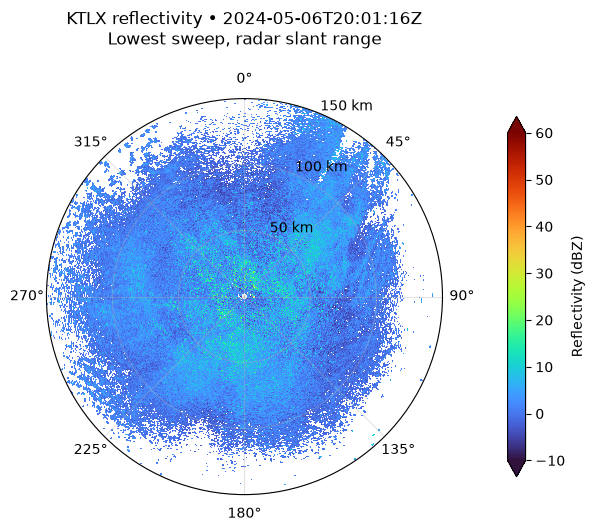

In [5]:
nearby = reflectivity.sel(range=slice(None, 150_000))
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": "polar"})
mesh = ax.pcolormesh(
    np.deg2rad(nearby.azimuth.values),
    nearby.range.values / 1000,
    nearby.values.T,
    shading="auto",
    cmap="turbo",
    vmin=-10,
    vmax=60,
)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_ylim(0, 150)
ax.set_yticks([50, 100, 150], ["50 km", "100 km", "150 km"])
ax.grid(alpha=0.35)
volume_start = str(radar["time_coverage_start"].item())
ax.set_title(
    f"{radar.attrs['instrument_name']} reflectivity • {volume_start}\n"
    "Lowest sweep, radar slant range",
    pad=20,
)
fig.colorbar(mesh, ax=ax, label="Reflectivity (dBZ)", shrink=0.78, extend="both", pad=0.12)
plt.show()

## Check the provenance and cache relationship

In-memory metadata refers to the original input, not the displayed subset or plot.
Keep the raw file and provenance for long-lived analyses; use manifests and their
lockfiles when an analysis needs reproducible multi-input restoration.

The format conventions come from [NOAA's RDA/RPG interface specification,
Table XVII-I notes 21 and 30](https://www.roc.noaa.gov/public-documents/icds/2620002Y.pdf).
See the [reader reference](https://docs.usdata.dev/reference/readers/) for limitations.

In [6]:
source = radar.attrs["usdata"]
assert source["provenance"]["checksum"] == item.provenance.checksum
again = fetch_asset(dataset, item.asset)
assert again.provenance.checksum == item.provenance.checksum
print("Asset ID:", source["asset_id"])
print("Same bytes verified and reused:", again.from_cache)
print("Source license:", item.provenance.license)

Asset ID: KTLX20240506_200116_V06
Same bytes verified and reused: True
Source license: US Government Work (public domain)
